-----
## **OBTENCIÓN DE ÁNGULOS EN FLECHAS SOBRE EL PAVIMENTO**
-----

**Autores: Junjing Wu , Yixuan Lu y Xianye Lin**

<br>

Utilizar una red YOLO-OBB no nos sirve porque no obtendríamos la orientación, sino el rectángulo rotado que mejor encaja con el objeto.

La propuesta para obtener la orientación de las flechas consiste en diseñar una CNN ad-hoc que entrenaremos con las imágenes de las flechas extraidas por YOLO y la rotación proporcionada en los labels.

Para ello se eliminarán todas las imágenes que no tienen flechas, y de las que sí tienen se recortará cada flecha (puede haber varias y se reescalará a unas dimensiones fijas (por determinar), añadiendo el ángulo reportado en los labels.

Con ese dataset se entrenará una red tipo VGG para obtener dada una imagen de una flecha el ángulo que forma.

#### Ajuste del ancho de visualización del notebook


In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

#### Importar librería PyTorch

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

#### Carga de imágenes y etiquetas desde un archivo de datos

In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
import math
import matplotlib.pyplot as plt

def load_samples (directory, size=None):
    data = pd.read_csv(directory, sep='\t', header=None) 

    #data = data[:10]
    print(data)
    
    X = []
    Y = []
    for i in range(len(data)):
        print('.', end='')
        # carga la imagen
        imgname = data.iloc[i,0]
        img = cv2.imread(imgname)
        if size != None:
            img = cv2.resize(img, size)
        X.append(img)
        Y.append(data.iloc[i,1])

    return (np.array(X), np.array(Y))

In [ ]:
X, Y = load_samples("dataset_cleaned.csv",(64,64)) 

                                                   0         1
0        dataset/lyrs=y&x=498928&y=388383&z=20-0.png  0.747256
1        dataset/lyrs=y&x=498933&y=388386&z=20-1.png  0.085187
2        dataset/lyrs=y&x=498934&y=388391&z=20-2.png  0.634782
3        dataset/lyrs=y&x=498934&y=388391&z=20-3.png  0.140102
4        dataset/lyrs=y&x=498940&y=388395&z=20-4.png  0.887765
...                                              ...       ...
6696  dataset/lyrs=y&x=530663&y=391686&z=20-7116.png  0.514914
6697  dataset/lyrs=y&x=530669&y=391622&z=20-7117.png  0.385349
6698  dataset/lyrs=y&x=530672&y=391647&z=20-7118.png  0.652626
6699  dataset/lyrs=y&x=530676&y=391636&z=20-7119.png  0.598877
6700  dataset/lyrs=y&x=530680&y=391631&z=20-7120.png  0.615035

[6701 rows x 2 columns]
...........................................................................................................................................................................................................................

#### División del conjunto de datos en entrenamiento y test


In [ ]:
print(X.shape)
print(Y.shape)

import sklearn.model_selection

X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.10, random_state=42) 

(6701, 64, 64, 3)
(6701,)


#### Visualización de ejemplos del conjunto de datos


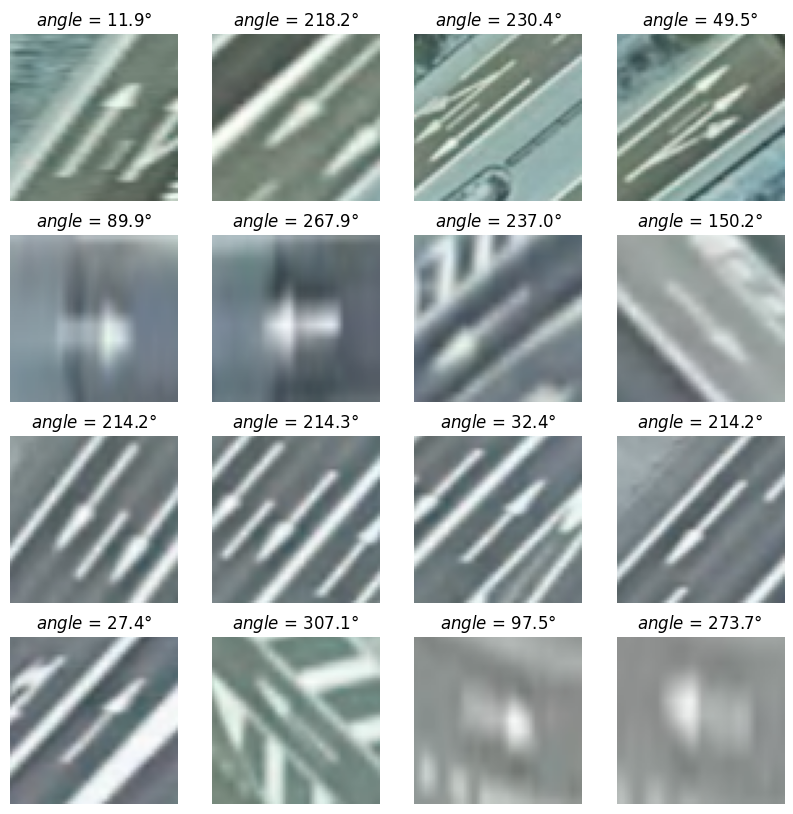

In [ ]:
# Imprime algunos ejemplos
N = 16

fig, axs = plt.subplots(N//4,4,figsize=(10, 10*N//16))
axs = axs.flatten()
plt.axis('off')

im0 = 567
for i in range(N):
    axs[i].axis('off')
    axs[i].imshow(X[im0+i])
    #axs[i].title.set_text(f"$angle$ = {(Y[im0+i]):.3f}")
    axs[i].title.set_text(f"$angle$ = {(360*Y[im0+i]):.1f}°")

#plt.savefig("test.png", bbox_inches='tight')

-----
## **PARTE 1: CNN desde 0**
-----

#### División del dataset 70/10/20 (train/val/test)

Esta celda de código realiza la **división del conjunto de datos en entrenamiento, validación y test con una proporción 70/10/20**. Primero se importan las librerías necesarias (`numpy` y `sklearn.model_selection`). A continuación, se utiliza la función `train_test_split` para separar inicialmente el **70 % de los datos para entrenamiento** (`X_tr`, `y_tr`) y el **30 % restante en un conjunto temporal** (`X_tmp`, `y_tmp`). Posteriormente, ese 30 % se vuelve a dividir con otro `train_test_split` para obtener aproximadamente un **10 % para validación** (`X_va`, `y_va`) y un **20 % para test** (`X_te`, `y_te`). Finalmente, el código imprime las dimensiones (`shape`) de cada conjunto para comprobar que la partición se ha realizado correctamente y también muestra el **rango mínimo y máximo de la variable objetivo `Y`**, lo que permite verificar la distribución de los valores de salida.

In [ ]:
X_tr, X_tmp, y_tr, y_tmp = sklearn.model_selection.train_test_split(
    X, Y, test_size=0.30, random_state=42
)  # 70% train, 30% tmp

X_va, X_te, y_va, y_te = sklearn.model_selection.train_test_split(
    X_tmp, y_tmp, test_size=2/3, random_state=42
)  # del 30% -> 10% val y 20% test

print("Shapes:")
print("  Train:", X_tr.shape, y_tr.shape)
print("  Val  :", X_va.shape, y_va.shape)
print("  Test :", X_te.shape, y_te.shape)
print("Y range:", float(np.min(Y)), float(np.max(Y)))


Shapes:
  Train: (4690, 64, 64, 3) (4690,)
  Val  : (670, 64, 64, 3) (670,)
  Test : (1341, 64, 64, 3) (1341,)
Y range: 0.0 0.999854653060414


#### Selección automática del dispositivo de cálculo

Definimos una función llamada `set_device` que selecciona automáticamente el **dispositivo de cálculo más adecuado para ejecutar el modelo con PyTorch**. Primero comprueba si está disponible **MPS (Metal Performance Shaders)**, que permite usar la GPU en equipos Apple. Si no está disponible, verifica si existe una **GPU compatible con CUDA**, que es la aceleración por GPU de NVIDIA. En caso de que ninguna de estas opciones esté disponible, el código utiliza la **CPU** como dispositivo de ejecución. Finalmente, la función imprime el dispositivo seleccionado y lo devuelve para almacenarlo en la variable `device`, que posteriormente se usará para mover el modelo y los tensores al hardware correspondiente.

In [45]:
def set_device():
    if torch.backends.mps.is_available():
        dev = torch.device("mps")
    elif torch.cuda.is_available():
        dev = torch.device("cuda")
    else:
        dev = torch.device("cpu")
    print(f"Using {dev} device")
    return dev

device = set_device()


Using cuda device


#### Conversión de datos a tensores de PyTorch y normalización

Definimos dos funciones auxiliares para **convertir los datos de NumPy a tensores de PyTorch y prepararlos para el entrenamiento del modelo**. La función `to_torch_image_batch` recibe un lote de imágenes en formato NumPy y las convierte a `torch.tensor`, normalizando los valores de píxeles al rango **[0, 1]** al dividir por 255.0. Además, cambia el formato de las imágenes de **NHWC (número de imágenes, alto, ancho, canales)** a **NCHW (número de imágenes, canales, alto, ancho)** mediante `permute`, que es el formato requerido por las redes convolucionales en PyTorch. También mueve directamente el tensor al dispositivo de cálculo seleccionado (`CPU`, `CUDA` o `MPS`). Por otro lado, la función `to_torch_y` convierte las etiquetas `Y` en un tensor de tipo `float32`, asegurando primero que los datos estén en formato NumPy y reorganizando su forma con `view(-1,1)` para que tengan una dimensión adecuada para el entrenamiento del modelo. Estas funciones facilitan la preparación eficiente de los datos antes de alimentar la red neuronal.

In [ ]:
# Tensor conversion (NHWC -> NCHW) + normalización
# Y está en vueltas [0..1] (360*Y)

def to_torch_image_batch(X_np, device):
    # Usamos 255.0 para que el rango sea exactamente [0.0, 1.0]
    # Movemos el tensor al dispositivo directamente
    Xt = torch.tensor(X_np, dtype=torch.float32, device=device) / 255.0
    return Xt.permute(0, 3, 1, 2).contiguous()

def to_torch_y(Y_np, device):
    # Evitamos crear un array redundante si Y_np ya es numpy array
    Y_np = np.asarray(Y_np) 
    # Creamos el tensor ya directamente en la gráfica (device)
    return torch.tensor(Y_np, dtype=torch.float32, device=device).view(-1, 1)

#### Funciones de entrenamiento y evaluación del modelo

Definimos las funciones principales para **entrenar y evaluar el modelo utilizando PyTorch y DataLoader**. La función `train_loop` implementa el proceso de entrenamiento durante un número determinado de épocas. En cada época el modelo se pone en **modo entrenamiento (`model.train()`)**, se recorren los batches del `DataLoader` de entrenamiento, se calculan las predicciones, la función de pérdida y se actualizan los pesos mediante **backpropagation** usando el optimizador. Después de cada época se realiza una **fase de validación**, donde el modelo pasa a modo evaluación (`model.eval()`) y se calcula la pérdida sobre el conjunto de validación sin actualizar los pesos. Las pérdidas de entrenamiento y validación se guardan en un diccionario `history` para poder analizar posteriormente la evolución del aprendizaje.

Además, la celda define la función `eval_dl`, que sirve para **evaluar el modelo sobre un DataLoader (por ejemplo, el conjunto de test)**. Esta función calcula opcionalmente el **MSE de la salida trigonométrica** y también una métrica más interpretable: el **error absoluto medio en grados (MAE_deg)**. Para ello convierte las salidas del modelo, representadas como **(coseno, seno)**, en ángulos mediante `atan2`, calcula la diferencia angular real entre predicción y valor verdadero, corrige el error teniendo en cuenta la naturaleza circular de los ángulos (evitando errores mayores de 180°) y finalmente lo convierte a grados. El resultado se devuelve en un diccionario con las métricas de evaluación del modelo.

In [ ]:
# Métrica: MAE en grados

from torch.utils.data import TensorDataset, DataLoader

def train_loop(dl_train, dl_val, model, loss_fn, optimizer, epochs=30, device='cpu', trace=1):
    model = model.to(device)
    
    # Listas para guardar el historial
    history = {'train_loss': [], 'val_loss': []}
    
    for e in range(epochs):
        model.train() # Modo entrenamiento
        loss_sum = 0.0
        n = 0
        
        # Bucle de entrenamiento
        for Xb, Yb in dl_train:
            Xb, Yb = Xb.to(device), Yb.to(device)

            optimizer.zero_grad()
            pred = model(Xb)
            loss = loss_fn(pred, Yb)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * Xb.size(0)
            n += Xb.size(0)
            
        train_loss = loss_sum / n
        history['train_loss'].append(train_loss)

        # Bucle de Validación (evaluar sin entrenar)
        model.eval()
        val_loss_sum = 0.0
        n_val = 0
        with torch.no_grad():
            for Xb, Yb in dl_val:
                Xb, Yb = Xb.to(device), Yb.to(device)
                pred = model(Xb)
                val_loss = loss_fn(pred, Yb)
                val_loss_sum += val_loss.item() * Xb.size(0)
                n_val += Xb.size(0)
                
        val_loss = val_loss_sum / n_val
        history['val_loss'].append(val_loss)

        if (e+1) % trace == 0:
            print(f"Epoch {e+1:>3d}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
            
    return history

@torch.no_grad()
def eval_dl(dl, model, loss_fn=None, device='cpu'):
    model = model.to(device)
    model.eval() # Modo evaluación (apaga Dropout, BatchNorm, etc.)

    mse_sum = 0.0
    mae_deg_sum = 0.0
    n = 0

    for Xb, Yb in dl:
        Xb, Yb = Xb.to(device), Yb.to(device)
        pred = model(Xb)

        # Calcular el Loss general (MSE Trigonométrico)
        if loss_fn is not None:
            mse_sum += loss_fn(pred, Yb).item() * Xb.size(0)

        # Calcular el Error Real en Grados (MAE)
        # Yb y pred son [Coseno, Seno]. Usamos atan2 para sacar el ángulo en radianes.
        # atan2 toma (y, x), que en este caso es (Seno, Coseno) (índice 1 y 0)
        true_angles = torch.atan2(Yb[:, 1], Yb[:, 0])
        pred_angles = torch.atan2(pred[:, 1], pred[:, 0])
        
        # Diferencia absoluta en radianes
        diff_rad = torch.abs(true_angles - pred_angles)
        
        #  El error máximo posible es PI (180 grados). 
        # Si la diferencia es mayor a PI, tomamos el camino inverso por el círculo.
        diff_rad = torch.minimum(diff_rad, 2.0 * math.pi - diff_rad)
        
        # Convertir a grados y sumar
        diff_deg = diff_rad * (180.0 / math.pi)
        mae_deg_sum += diff_deg.sum().item()
        
        n += Xb.size(0)

    # Preparar el diccionario de salida
    out = {}
    if loss_fn is not None:
        out["MSE"] = mse_sum / n
    out["MAE_deg"] = mae_deg_sum / n  
    
    return out

#### Creación de los DataLoaders

Preparamos los datos para el entrenamiento del modelo creando los **DataLoaders de PyTorch**. Primero se define el tamaño del lote (`batch size`) con `bs = 64`, que indica cuántas imágenes se procesarán simultáneamente durante el entrenamiento. A continuación, los conjuntos de entrenamiento, validación y test se convierten a **tensores de PyTorch** utilizando las funciones auxiliares `to_torch_image_batch` (para las imágenes) y `to_torch_y` (para las etiquetas), además de moverlos al dispositivo de cálculo seleccionado (`CPU`, `CUDA` o `MPS`). Posteriormente, se crean los `TensorDataset`, que agrupan imágenes y etiquetas en pares `(X, Y)`. Finalmente, se construyen los `DataLoader` para cada conjunto: `train_loader` con mezcla aleatoria de los datos (`shuffle=True`) para mejorar el aprendizaje del modelo, y `val_loader` y `test_loader` sin mezcla (`shuffle=False`), ya que estos se utilizan únicamente para evaluar el rendimiento del modelo.

In [48]:
# Crear DataLoaders

bs = 64

Xt_tr = to_torch_image_batch(X_tr, device)
Yt_tr = to_torch_y(y_tr, device)

Xt_va = to_torch_image_batch(X_va, device)
Yt_va = to_torch_y(y_va, device)

Xt_te = to_torch_image_batch(X_te, device)
Yt_te = to_torch_y(y_te, device)

train_loader = DataLoader(TensorDataset(Xt_tr, Yt_tr), batch_size=bs, shuffle=True)
val_loader  = DataLoader(TensorDataset(Xt_va, Yt_va), batch_size=bs, shuffle=False)
test_loader  = DataLoader(TensorDataset(Xt_te, Yt_te), batch_size=bs, shuffle=False)


#### Cálculo del coeficiente R² para la representación trigonométrica

Definimos la función `calcular_r2_trigonometrico`, que evalúa el rendimiento del modelo utilizando el **coeficiente de determinación R²** sobre las predicciones trigonométricas del ángulo. La función coloca el modelo en **modo evaluación (`model.eval()`)** y desactiva el cálculo de gradientes con `@torch.no_grad()` para mejorar la eficiencia durante la evaluación. A continuación, recorre los datos del `DataLoader`, obtiene las predicciones del modelo y las **normaliza para asegurar que formen un vector unitario (coseno, seno)**. Posteriormente, guarda las predicciones y los valores reales en listas y los combina en arrays de NumPy. Finalmente, calcula tres métricas usando `r2_score`: el **R² del coseno**, el **R² del seno** y un **R² global** considerando ambas componentes conjuntamente. Estos valores permiten medir qué tan bien el modelo predice la dirección de la flecha en su representación trigonométrica. Ya que el R² normal no mide bien las relaciones circulares como los grados de las flechas , por lo que lo cambiamos a R² trigonométrico que es más adecuado para este tipo de datos.

In [54]:
from sklearn.metrics import r2_score
@torch.no_grad()
def calcular_r2_trigonometrico(dl, model, device='cpu'):
    model = model.to(device)
    model.eval()
    
    y_true_list, y_pred_list = [], []
    
    for Xb, Yb in dl:
        Xb = Xb.to(device)
        pred = model(Xb)
        pred = pred / (pred.norm(dim=1, keepdim=True) + 1e-8)
        
        y_pred_list.append(pred.cpu().numpy())
        y_true_list.append(Yb.cpu().numpy())
        
    y_true_all = np.vstack(y_true_list)
    y_pred_all = np.vstack(y_pred_list)
    
    r2_cos = r2_score(y_true_all[:, 0], y_pred_all[:, 0])
    r2_sin = r2_score(y_true_all[:, 1], y_pred_all[:, 1])
    r2_global = r2_score(y_true_all, y_pred_all)
    
    return r2_global, r2_cos, r2_sin

#### **A) CNN ad-hoc (mejorada, pero simple y estable)**

#### Transformación trigonométrica de las etiquetas y preparación de los nuevos DataLoaders

Implementamos la **representación trigonométrica del ángulo** para mejorar el aprendizaje del modelo. Primero se define la función `y_to_trig`, que transforma las etiquetas `Y` expresadas en **vueltas normalizadas entre 0 y 1** en coordenadas **(coseno, seno)**. Para ello, el valor se convierte primero a **radianes** multiplicándolo por 2pi, y después se calculan las componentes trigonométricas usando `torch.cos` y `torch.sin`. El resultado es un vector de dos valores por muestra que representa la dirección de la flecha en el círculo unitario, evitando el problema de discontinuidad entre **0° y 360°**.

A continuación, esta transformación se aplica a los conjuntos de **entrenamiento, validación y test**, generando nuevas etiquetas (`Yt_tr2`, `Yt_va2`, `Yt_te2`). Posteriormente se crean nuevos **DataLoaders** (`train_loader2`, `val_loader2`, `test_loader2`) que combinan las imágenes con estas etiquetas trigonométricas y las agrupan en **batches de 64 muestras** para facilitar el entrenamiento en la GPU o CPU.

Finalmente, se define la función de pérdida `trig_loss`, que calcula el **error cuadrático medio (MSE)** entre las coordenadas trigonométricas predichas por el modelo y las reales. Dado que ambas representan puntos en el círculo unitario, esta pérdida equivale a medir la **distancia entre el punto predicho y el punto real en el plano**, lo que permite entrenar el modelo para aprender correctamente la dirección del ángulo.

In [ ]:
import math
import torch
import numpy as np
from torch import nn
from torch.utils.data import TensorDataset, DataLoader 

# Transformaciçon trigonométrica
def y_to_trig(Y_np, device):
    """
    Convierte un valor de [0 a 1] vueltas a coordenadas (Coseno, Seno)
    para evitar el problema de que el 0º y el 360º estén separados numéricamente.
    """
    # Creamos el tensor directamente en la tarjeta gráfica (device)
    # y evitamos copias innecesarias en memoria con np.array()
    y_tensor = torch.tensor(Y_np, dtype=torch.float32, device=device)
    
    # Convertir (0-1) a Radianes (0 a 2*PI)
    theta = y_tensor.view(-1, 1) * (2.0 * math.pi)
    
    # Calcular Coseno y Seno y juntarlos en 2 columnas (dim=1)
    #Para cada imagen, ahora tenemos [X, Y] en lugar de un solo ángulo.
    Yt = torch.cat([torch.cos(theta), torch.sin(theta)], dim=1)
    
    return Yt

# Aplicar la transformación a los 3 conjuntos de etiquetas
Yt_tr2 = y_to_trig(y_tr, device)
Yt_va2 = y_to_trig(y_va, device)
Yt_te2 = y_to_trig(y_te, device)

# Creación de dataloaders

# Los DataLoader empaquetan las imágenes (Xt) y las nuevas etiquetas trigonométricas (Yt)
# en "batches" (cajas de 64 en 64) para no saturar la memoria gráfica.
train_loader2 = DataLoader(TensorDataset(Xt_tr, Yt_tr2), batch_size=64, shuffle=True)
val_loader2   = DataLoader(TensorDataset(Xt_va, Yt_va2), batch_size=64, shuffle=False)
test_loader2  = DataLoader(TensorDataset(Xt_te, Yt_te2), batch_size=64, shuffle=False)


# Loss function
def trig_loss(pred, target):
    """
    Calcula el Error Cuadrático Medio (MSE) entre las coordenadas (cos, sin) predichas
    y las coordenadas (cos, sin) reales.
    """
    # Como target y pred son puntos en un círculo 2D, 
    # esto calcula la distancia recta entre esos dos puntos.
    return ((pred - target)**2).mean()

#### Definición de la arquitectura de la red neuronal convolucional (CNN)

Definimos la arquitectura de una **red neuronal convolucional profunda (`cnn2`)** utilizando `nn.Sequential` de PyTorch. La red está organizada en varios **bloques convolucionales** que extraen características de las imágenes de forma progresiva. En cada bloque se utilizan capas `Conv2d` para detectar patrones visuales, seguidas de `BatchNorm2d` para estabilizar el entrenamiento y `ReLU` como función de activación. Además, al final de varios bloques se emplea `MaxPool2d` para **reducir la resolución espacial de las imágenes**, lo que permite que la red capture características cada vez más abstractas.

La arquitectura incrementa gradualmente el número de filtros (**32 → 64 → 128 → 256 → 512**), permitiendo detectar patrones cada vez más complejos. En los bloques más profundos se añaden capas convolucionales adicionales para aumentar la capacidad del modelo. Posteriormente, la capa `AdaptiveAvgPool2d` reduce la salida espacial a un tamaño fijo `(1×1)`, independientemente del tamaño original de la imagen, y `Flatten` convierte los mapas de características en un vector.

Finalmente, la red incluye una **parte densa (fully connected)** con capas `Linear`, activaciones `ReLU` y `Dropout` para reducir el sobreajuste. La última capa produce **dos valores de salida**, que representan las coordenadas trigonométricas **(coseno, seno)** del ángulo de la flecha. El modelo completo se mueve al dispositivo de cálculo seleccionado (`device`) para aprovechar GPU o CPU durante el entrenamiento.

* Hemos definido la CNN de esta manera con el objetivo de construir una red lo suficientemente profunda para captar patrones complejos, pero controlando el sobreajuste. Para ello, aumentamos progresivamente los filtros y la profundidad, mientras incorporamos **Batch Normalization**, **MaxPooling** y **Dropout**, lo que permite mejorar la generalización y evitar que el modelo memorice los datos.


In [ ]:
cnn2 = nn.Sequential(
    # Bloque 1 
    nn.Conv2d(3, 32, 3, padding=1, bias=False),
    nn.BatchNorm2d(32), nn.ReLU(),
    nn.Conv2d(32, 32, 3, padding=1, bias=False),
    nn.BatchNorm2d(32), nn.ReLU(),
    nn.MaxPool2d(2,2),   

    # Bloque 2 
    nn.Conv2d(32, 64, 3, padding=1, bias=False),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.Conv2d(64, 64, 3, padding=1, bias=False),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(2,2),   

    # Bloque 3 (Añadimos 1 capa extra)
    nn.Conv2d(64, 128, 3, padding=1, bias=False),
    nn.BatchNorm2d(128), nn.ReLU(),
    nn.Conv2d(128, 128, 3, padding=1, bias=False),
    nn.BatchNorm2d(128), nn.ReLU(),
    nn.Conv2d(128, 128, 3, padding=1, bias=False), 
    nn.BatchNorm2d(128), nn.ReLU(),
    nn.MaxPool2d(2,2),   

    # Bloque 4 (Completado y más profundo) 
    nn.Conv2d(128, 256, 3, padding=1, bias=False),
    nn.BatchNorm2d(256), nn.ReLU(),
    nn.Conv2d(256, 256, 3, padding=1, bias=False), 
    nn.BatchNorm2d(256), nn.ReLU(),
    nn.Conv2d(256, 256, 3, padding=1, bias=False),
    nn.BatchNorm2d(256), nn.ReLU(),
    nn.MaxPool2d(2,2), # Reducimos tamaño espacial una vez más

    # Bloque 5 
    nn.Conv2d(256, 512, 3, padding=1, bias=False),
    nn.BatchNorm2d(512), nn.ReLU(),
    nn.Conv2d(512, 512, 3, padding=1, bias=False),
    nn.BatchNorm2d(512), nn.ReLU(),
    
    # Extrae la conclusión final 
    nn.AdaptiveAvgPool2d((1,1)),  # (B, 512, 1, 1) No importa el tamaño original de la foto
    nn.Flatten(),                 # (B, 512)
    
    # Red Neuronal Densa (Aumentamos un poco las neuronas al tener más filtros)
    nn.Dropout(0.40),             # Subimos un poco el Dropout para evitar memorizar
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.25),
    nn.Linear(256, 128),
    nn.ReLU(),
    
    # Salida 
    nn.Linear(128, 2),            # (cos, sin)
).to(device)


#### Entrenamiento del modelo y visualización de la curva de aprendizaje

Ejecutamos el **entrenamiento de la red neuronal convolucional (`cnn2`)** utilizando el optimizador `AdamW`, que combina el algoritmo Adam con regularización mediante `weight_decay` para mejorar la generalización del modelo. Se establece una **tasa de aprendizaje de 3e-4** y un `weight_decay` de `1e-4`. Posteriormente, se llama a la función `train_loop`, pasando los `DataLoader` de entrenamiento y validación (`train_loader2` y `val_loader2`), el modelo, la función de pérdida `trig_loss`, el optimizador y el número de épocas (`40`). Durante el entrenamiento se guardan en la variable `history` los valores de pérdida de entrenamiento y validación para cada época.

Después del entrenamiento, la celda genera una **gráfica de la curva de aprendizaje** utilizando `matplotlib`. En esta gráfica se muestran las pérdidas de entrenamiento y validación a lo largo de las épocas, lo que permite analizar cómo evoluciona el aprendizaje del modelo y detectar posibles problemas como **sobreajuste (overfitting)** o **subentrenamiento**. La gráfica incluye título, etiquetas de los ejes, leyenda y una cuadrícula para facilitar la interpretación de los resultados.

Epoch   5/40 | Train Loss: 0.062375 | Val Loss: 0.089468
Epoch  10/40 | Train Loss: 0.041649 | Val Loss: 0.077959
Epoch  15/40 | Train Loss: 0.015975 | Val Loss: 0.064535
Epoch  20/40 | Train Loss: 0.021162 | Val Loss: 0.073666
Epoch  25/40 | Train Loss: 0.014538 | Val Loss: 0.051713
Epoch  30/40 | Train Loss: 0.012201 | Val Loss: 0.068409
Epoch  35/40 | Train Loss: 0.020253 | Val Loss: 0.074358
Epoch  40/40 | Train Loss: 0.013474 | Val Loss: 0.069399


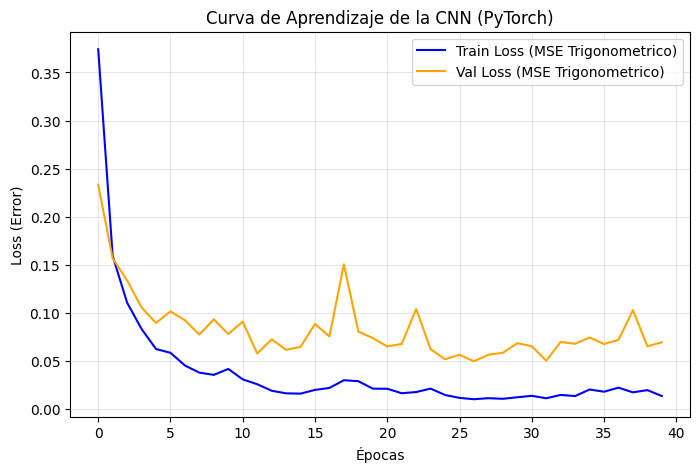

In [ ]:
# Entrenamos y guardamos el resultado en 'history'
opt2 = torch.optim.AdamW(cnn2.parameters(), lr=3e-4, weight_decay=1e-4)
history = train_loop(train_loader2, val_loader2, cnn2, trig_loss, opt2, epochs=40, device=device, trace=5)

# Gráfica del error
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss (MSE Trigonometrico)', color='blue')
plt.plot(history['val_loss'], label='Val Loss (MSE Trigonometrico)', color='orange')
plt.title('Curva de Aprendizaje de la CNN (PyTorch)')
plt.xlabel('Épocas')
plt.ylabel('Loss (Error)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Cálculo de la precisión angular y métricas de evaluación en el conjunto de test

Definimos la función `trig_accuracy`, que permite calcular la **precisión del modelo en términos de error angular**. Para ello evaluamos el modelo sobre un `DataLoader` y comparamos las predicciones con las etiquetas reales, ambas representadas como vectores trigonométricos **(coseno, seno)**. Primero normalizamos los vectores predichos y reales para asegurar que estén sobre el círculo unitario. Después calculamos el **producto escalar** entre ambos vectores y obtenemos el error angular utilizando la función `acos`, que devuelve el ángulo entre ellos. Este error se convierte a grados y se comprueba si está por debajo de un umbral (`thr_deg`). La precisión final se calcula como el porcentaje de predicciones cuyo error angular está dentro de ese margen.

A continuación utilizamos esta función para calcular tres métricas de precisión sobre el conjunto de test: **ACC@5°, ACC@10° y ACC@15°**, que indican el porcentaje de predicciones cuyo error es menor o igual a 5, 10 o 15 grados respectivamente. También calculamos el **coeficiente de determinación R²** utilizando la función `calcular_r2_trigonometrico`, obteniendo un valor global y los valores individuales para las componentes de coseno y seno. Finalmente mostramos todas estas métricas por pantalla para evaluar el rendimiento del modelo de forma completa.

In [ ]:
@torch.no_grad()
def trig_accuracy(dl, model, device='cpu', thr_deg=10):
    model = model.to(device)
    model.eval()
    ok = 0
    n = 0
    for Xb, Yb in dl:
        Xb, Yb = Xb.to(device), Yb.to(device)
        pred = model(Xb)

        # normaliza por si acaso
        pred = pred / (pred.norm(dim=1, keepdim=True) + 1e-8)
        Yb   = Yb   / (Yb.norm(dim=1, keepdim=True) + 1e-8)

        dot = (pred * Yb).sum(dim=1).clamp(-1.0, 1.0)
        err_deg = torch.acos(dot) * (180.0 / math.pi)  # (B,)

        ok += (err_deg <= thr_deg).sum().item()
        n  += err_deg.numel()
    return ok / n

# Calculamos Accuracy
acc5  = trig_accuracy(test_loader2, cnn2, device=device, thr_deg=5)
acc10 = trig_accuracy(test_loader2, cnn2, device=device, thr_deg=10)
acc15 = trig_accuracy(test_loader2, cnn2, device=device, thr_deg=15)

# Calculamos R2
r2_global, r2_cos, r2_sin = calcular_r2_trigonometrico(test_loader2, cnn2, device=device)

# Imprimimos todo por pantalla
print("       Métricas en test")

print(f"ACC@5°:  {acc5*100:.2f}%")
print(f"ACC@10°: {acc10*100:.2f}%")
print(f"ACC@15°: {acc15*100:.2f}%")

print(f"R² Global: {r2_global:.4f}")
print(f"R² Coseno: {r2_cos:.4f}")
print(f"R² Seno:   {r2_sin:.4f}")



-----------------------------------
       MÉTRICAS EN TEST
-----------------------------------
ACC@5°:  54.29%
ACC@10°: 80.01%
ACC@15°: 90.90%
-----------------------------------
R² Global: 0.8595
R² Coseno: 0.8632
R² Seno:   0.8557
-----------------------------------


#### Visualización de predicciones del modelo sobre imágenes de test

Definimos la función `visualizar_predicciones_trig`, que permite **comparar visualmente las predicciones del modelo con los valores reales** utilizando algunas imágenes del conjunto de test. Primero colocamos el modelo en **modo evaluación**, obtenemos un batch del `DataLoader` de test y calculamos las predicciones de la red sin calcular gradientes. Posteriormente convertimos los tensores a arrays de NumPy para poder trabajar con ellos y visualizarlos con `matplotlib`.

Para cada imagen seleccionada, convertimos el tensor de formato **(canales, alto, ancho)** al formato **(alto, ancho, canales)** que requiere Matplotlib. Después calculamos el **ángulo real y el ángulo predicho** utilizando la función `atan2` a partir de las coordenadas trigonométricas **(coseno, seno)**. A continuación mostramos la imagen y dibujamos dos flechas desde el centro: una **verde que representa el ángulo real** y una **roja discontinua que representa la predicción del modelo**. Finalmente mostramos también en el título los ángulos en grados para facilitar la comparación entre ambos valores, lo que permite evaluar visualmente la precisión de las predicciones de la red neuronal.

Flecha Verde: Real | Flecha Roja: Predicción de la red


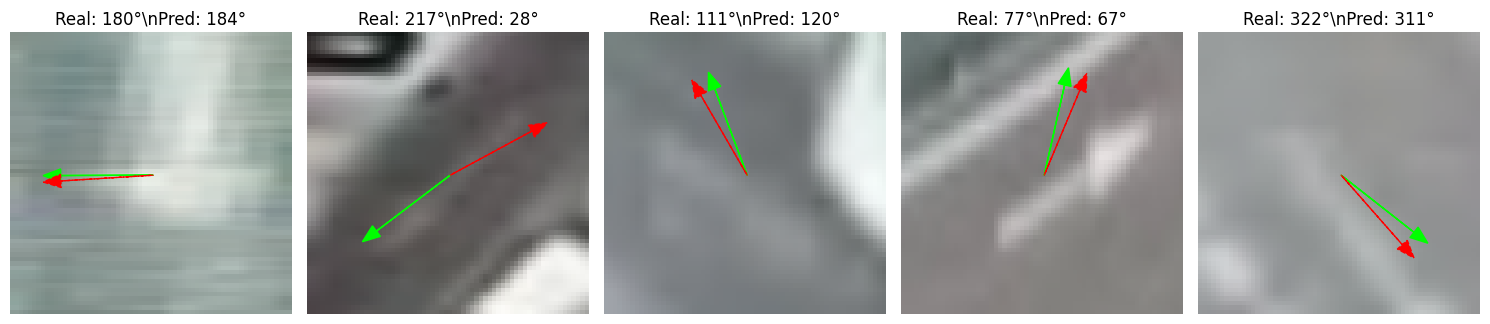

In [ ]:
import math

def visualizar_predicciones_trig(dl_test, model, device='cpu', num_images=5):
    model = model.to(device)
    model.eval() # Modo evaluación
    
    # Sacar un batch del dataloader de Test
    Xb, Yb = next(iter(dl_test))
    Xb, Yb = Xb.to(device), Yb.to(device)
    
    with torch.no_grad():
        preds = model(Xb)
        
    # Pasar a la CPU
    X_np = Xb.cpu().numpy()
    Y_np = Yb.cpu().numpy()
    preds_np = preds.cpu().numpy()
    
    plt.figure(figsize=(15, 5))
    
    for i in range(min(num_images, len(X_np))):
        ax = plt.subplot(1, num_images, i + 1)
        
        # PyTorch usa el formato (Canales, Alto, Ancho)
        # Matplotlib necesita (Alto, Ancho, Canales) 
        img = np.transpose(X_np[i], (1, 2, 0))


        img = np.clip(img, 0, 1) if img.max() <= 1.0 else np.clip(img/255.0, 0, 1)
        
        # Como Y predice [cos(a), sin(a)], usamos atan2 para sacar el ángulo en radianes
        # np.arctan2( y, x )
        angle_true = math.atan2(Y_np[i][1], Y_np[i][0])
        angle_pred = math.atan2(preds_np[i][1], preds_np[i][0])
        
        plt.imshow(img)
        plt.axis('off')
        
        # Centro de la imagen y longitud de la flecha
        center = img.shape[0] // 2
        length = img.shape[0] // 3
        
        # Dibujar flecha real (Verde)
        dx_true = length * math.cos(angle_true)
        dy_true = -length * math.sin(angle_true) # Negativo porque el eje Y va hacia abajo
        ax.arrow(center, center, dx_true, dy_true, head_width=3, head_length=4, fc='lime', ec='lime')
        
        # Dibujar flecha predicha (Rojo punteado)
        dx_pred = length * math.cos(angle_pred)
        dy_pred = -length * math.sin(angle_pred)
        ax.arrow(center, center, dx_pred, dy_pred, head_width=3, head_length=4, fc='red', ec='red', linestyle='--')
        
        # Título en grados
        deg_true = (angle_true * 180 / math.pi) % 360
        deg_pred = (angle_pred * 180 / math.pi) % 360
        plt.title(f"Real: {deg_true:.0f}°\\nPred: {deg_pred:.0f}°")

    plt.tight_layout()
    plt.show()

# Ejecutar visualización
print("Flecha Verde: Real | Flecha Roja: Predicción de la red")
visualizar_predicciones_trig(test_loader2, cnn2, device=device, num_images=5)

#### Evaluación final del modelo en el conjunto de test

Calculamos y mostramos **las métricas finales del modelo utilizando el conjunto de test**. Primero utilizamos la función `eval_dl` para obtener el **error cuadrático medio (MSE)** entre las coordenadas trigonométricas predichas y las reales, así como el **error absoluto medio en grados (MAE)**, que indica cuántos grados se desvía la predicción del modelo respecto al ángulo real de la flecha. Esta métrica es especialmente útil porque permite interpretar directamente el error del modelo en términos de orientación angular.

A continuación calculamos la **precisión angular del modelo** utilizando la función `trig_accuracy`. Esta métrica mide el porcentaje de predicciones que se encuentran dentro de un margen de error determinado. En concreto evaluamos tres tolerancias diferentes: **±5°, ±10° y ±15°**, lo que permite analizar qué proporción de flechas se predicen con una precisión muy alta, media o más flexible. Finalmente mostramos todas estas métricas por pantalla para obtener una visión clara del rendimiento final del modelo sobre datos no vistos durante el entrenamiento.

In [ ]:

print("   Resultados finales en el conjunto de test   ")


# Calcular el Error Medio (¿Por cuántos grados nos desviamos de media?)
# Usamos la función eval_dl que corregimos previamente
test_metrics = eval_dl(test_loader2, cnn2, loss_fn=trig_loss, device=device)

print(f" Error Medio Cuadrático (MSE): {test_metrics['MSE']:.6f}")
print(f" Desviación Media (MAE):       {test_metrics['MAE_deg']:.2f} grados de error de media")


print("   Porcentaje de acierto según tolerancia  ")

# Calcular la precisión (Accuracy) usando la genial función trigonométrica
acc5  = trig_accuracy(test_loader2, cnn2, device=device, thr_deg=5)
acc10 = trig_accuracy(test_loader2, cnn2, device=device, thr_deg=10)
acc15 = trig_accuracy(test_loader2, cnn2, device=device, thr_deg=15)

print(f" Flechas acertadas con ±5° de margen:  {acc5*100:.2f}%")
print(f" Flechas acertadas con ±10° de margen: {acc10*100:.2f}%")
print(f" Flechas acertadas con ±15° de margen: {acc15*100:.2f}%")


   RESULTADOS FINALES EN EL CONJUNTO DE TEST   
• Error Medio Cuadrático (MSE): 0.059535
• Desviación Media (MAE):       10.75 grados de error de media
--------------------------------------------------
   PORCENTAJE DE ACIERTO SEGÚN TOLERANCIA   
--------------------------------------------------
• Flechas acertadas con ±5° de margen:  54.29%
• Flechas acertadas con ±10° de margen: 80.01%
• Flechas acertadas con ±15° de margen: 90.90%


#### Conclusión final del modelo CNN entrenado desde cero

Observamos que el modelo **cnn2 entrenado desde cero** consigue un rendimiento sólido en el problema de predicción angular. Las métricas obtenidas en el conjunto de test muestran una **precisión elevada**, alcanzando aproximadamente un **90.9% de acierto con un margen de ±15°** y un **80% con ±10°**, lo que indica que el modelo es capaz de predecir la orientación de las flechas con bastante fiabilidad. Incluso en un margen más exigente (±5°), se obtiene un resultado razonable (~54%), lo que refleja una buena precisión fina.

El valor de **R² global (~0.86)** confirma que el modelo explica correctamente la variabilidad de los datos, tanto en las componentes de coseno como de seno, lo que indica una representación trigonométrica bien aprendida. Además, el **error medio absoluto (~10.75°)** es relativamente bajo, lo que refuerza la idea de que las predicciones son cercanas al valor real en términos angulares.

Por otro lado, la **curva de aprendizaje** muestra una convergencia clara: el error de entrenamiento disminuye de forma continua y el de validación se estabiliza en valores bajos, aunque con cierta separación entre ambas curvas, lo que sugiere un ligero sobreajuste. Sin embargo, este efecto no es crítico y el modelo mantiene una buena capacidad de generalización.

En conjunto, concluimos que el entrenamiento desde cero proporciona **resultados robustos y precisos**, siendo capaz de resolver correctamente el problema, aunque como se ha visto posteriormente, puede ser superado por enfoques basados en modelos preentrenados cuando se dispone de ellos.

---

## Preparación de modelos preentrenados para transfer learning

Definimos las herramientas necesarias para utilizar **modelos preentrenados mediante transfer learning**. Primero creamos la clase `L2Normalize`, una capa personalizada que normaliza la salida del modelo para que el vector resultante tenga norma 2 igual a 1. De esta forma garantizamos que la predicción final represente correctamente un punto del círculo unitario en formato **(coseno, seno)**.

A continuación definimos la clase `ImageNetWrapper`, que actúa como un **envoltorio del modelo base** y aplica automáticamente la **normalización estándar de ImageNet** a las imágenes de entrada. Esta normalización es necesaria porque los modelos preentrenados de `torchvision` fueron entrenados con imágenes normalizadas utilizando unas medias y desviaciones estándar específicas.

Posteriormente implementamos la función `build_transfer_model`, que permite **construir diferentes arquitecturas preentrenadas** (`VGG16`, `MobileNetV2` o `ResNet18`). Para cada modelo cargamos los **pesos preentrenados en ImageNet** y, opcionalmente, congelamos sus parámetros (`freeze_base=True`) para evitar que se actualicen durante el entrenamiento. Después reemplazamos la **última capa de clasificación** por una nueva capa `Linear` que produce dos valores de salida, correspondientes a **(coseno, seno)**, seguida de la capa `L2Normalize` para asegurar que el vector predicho esté normalizado. Finalmente devolvemos el modelo envuelto con `ImageNetWrapper`, listo para ser entrenado en la tarea de predicción del ángulo de la flecha.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T

# Recuperamos nuestra capa mágica trigonométrica
class L2Normalize(nn.Module):
    def forward(self, x):
        return F.normalize(x, p=2, dim=1)

# Envoltorio para normalizar los colores como exige ImageNet
class ImageNetWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        # Normalización oficial de ImageNet
        self.normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.base_model = base_model
        
    def forward(self, x):
        # Primero normaliza los colores, luego pasa por la red
        return self.base_model(self.normalize(x))

# Función constructora de modelos Pre-entrenados
def build_transfer_model(model_name='vgg16', freeze_base=True):
    
    if model_name == 'vgg16':
        # Cargar VGG16 preentrenada
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        # Congelar
        if freeze_base:
            for param in model.parameters():
                param.requires_grad = False
                
        # Cambiar la última capa del clasificador (de 1000 clases a 2 + L2Normalize)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Linear(in_features, 2),
            L2Normalize()
        )
        
    elif model_name == 'mobilenet_v2':
        # Cargar MobileNetV2
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        if freeze_base:
            for param in model.parameters():
                param.requires_grad = False
                
        # Cambiar la cabeza de MobileNet
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Linear(in_features, 2),
            L2Normalize()
        )
        
    elif model_name == 'resnet18':
        # Cargar ResNet18 (Suele ser la mejor en relación velocidad/precisión)
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        if freeze_base:
            for param in model.parameters():
                param.requires_grad = False
                
        # Cambiar la cabeza de ResNet (se llama 'fc' en lugar de classifier)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 2),
            L2Normalize()
        )
    else:
        raise ValueError("Modelo no soportado")

    # Envolvemos el modelo con el normalizador de ImageNet
    final_model = ImageNetWrapper(model)
    return final_model

#### Entrenamiento y comparación de modelos mediante transfer learning

Realizamos una comparación entre varios modelos preentrenados utilizando transfer learning. Para ello definimos una lista de arquitecturas a evaluar (`MobileNetV2`, `ResNet18` y `VGG16`) y creamos un bucle que entrena cada modelo de forma independiente. En cada iteración construimos el modelo mediante la función `build_transfer_model`, congelando los pesos del modelo base (`freeze_base=True`) para entrenar únicamente la nueva capa final que predice las coordenadas trigonométricas (coseno, seno).

A continuación definimos un optimizador `AdamW`, al que le pasamos únicamente los parámetros que requieren gradiente, es decir, los de la capa final añadida al modelo. Posteriormente entrenamos cada arquitectura utilizando la función `train_loop`, empleando los `DataLoader` de entrenamiento y validación y la función de pérdida trigonométrica `trig_loss`.

Una vez finalizado el entrenamiento, evaluamos cada modelo utilizando el conjunto de test. Calculamos la precisión angular con dos niveles de tolerancia (±5° y ±15°) mediante la función `trig_accuracy`, y también calculamos el coeficiente de determinación R² utilizando `calcular_r2_trigonometrico`, tanto de forma global como para las componentes de coseno y seno. Todos los resultados se almacenan en el diccionario `resultados_transfer`.


In [ ]:
# Lista de modelos a probar
model_names = ['mobilenet_v2', 'resnet18', 'vgg16']
resultados_transfer = {}

for name in model_names:
    print(f"   Entrenando modelo {name.upper()}")
    
    # Crear el modelo
    # Lo pasamos a la GPU (device)
    model_tl = build_transfer_model(model_name=name, freeze_base=True).to(device)
    
    # Optimizador (Solo le pasamos los parámetros que requieren gradiente, es decir, la cabeza nueva)
    params_to_update = [p for p in model_tl.parameters() if p.requires_grad]
    optimizer_tl = torch.optim.AdamW(params_to_update, lr=1e-3, weight_decay=1e-4)
    
    # Ponemos menos épocas (ej: 15) porque al ser Transfer Learning aprende MUY rápido
    history_tl = train_loop(train_loader2, val_loader2, model_tl, trig_loss, optimizer_tl, epochs=40, device=device, trace=5)
    
    # Evaluar en Test
    print(f"\n Evaluando {name.upper()} en Test")
    acc5  = trig_accuracy(test_loader2, model_tl, device=device, thr_deg=5)
    acc15 = trig_accuracy(test_loader2, model_tl, device=device, thr_deg=15)
    

    r2_global, r2_cos, r2_sin = calcular_r2_trigonometrico(test_loader2, model_tl, device=device)
    
    print(f"Accuracy ±5°:  {acc5*100:.2f}%")
    print(f"Accuracy ±15°: {acc15*100:.2f}%")
    print(f"R² Global:     {r2_global:.4f} (Cos: {r2_cos:.4f} | Sin: {r2_sin:.4f})")
    
    # Guardar resultados (añadimos r2_global para guardarlo en la memoria)
    resultados_transfer[name] = {
        'history': history_tl, 
        'acc5': acc5, 
        'acc15': acc15,
        'r2_global': r2_global
    }


print("Tabla de reultados finales (transfer learning congelado)")

print(f"{'Modelo':<15} | {'Accuracy ±5°':<15} | {'Accuracy±15°':<15} | {'R² global':<10}")

for name, data in resultados_transfer.items():
    print(f"{name.upper():<15} | {data['acc5']*100:>10.2f}%    | {data['acc15']*100:>10.2f}%    | {data['r2_global']:>9.4f}")



   ENTRENANDO MODELO: MOBILENET_V2
Epoch   5/40 | Train Loss: 0.892637 | Val Loss: 0.968704
Epoch  10/40 | Train Loss: 0.829321 | Val Loss: 0.936686
Epoch  15/40 | Train Loss: 0.819999 | Val Loss: 0.933069
Epoch  20/40 | Train Loss: 0.794858 | Val Loss: 0.949651
Epoch  25/40 | Train Loss: 0.776348 | Val Loss: 0.956238
Epoch  30/40 | Train Loss: 0.777261 | Val Loss: 0.959921
Epoch  35/40 | Train Loss: 0.761722 | Val Loss: 0.953133
Epoch  40/40 | Train Loss: 0.770420 | Val Loss: 0.960452

--- Evaluando MOBILENET_V2 en Test ---
Accuracy ±5°:  3.21%
Accuracy ±15°: 10.07%
R² Global:     -0.8042 (Cos: -0.8536 | Sin: -0.7547)

   ENTRENANDO MODELO: RESNET18
Epoch   5/40 | Train Loss: 0.876377 | Val Loss: 0.979514
Epoch  10/40 | Train Loss: 0.855075 | Val Loss: 0.945215
Epoch  15/40 | Train Loss: 0.824687 | Val Loss: 0.925370
Epoch  20/40 | Train Loss: 0.791228 | Val Loss: 0.932250
Epoch  25/40 | Train Loss: 0.786498 | Val Loss: 0.903545
Epoch  30/40 | Train Loss: 0.758313 | Val Loss: 0.90636

#### Conclusión de los resultados con transfer learning (modelo base congelado)

Observamos que el uso de **transfer learning con el modelo base congelado** produce un rendimiento muy limitado en esta tarea. Aunque permite entrenar de forma rápida y con bajo coste computacional, los resultados obtenidos son claramente insuficientes, con **valores de accuracy muy bajos y coeficientes R² negativos**, lo que indica que los modelos no están capturando adecuadamente la relación entre la imagen y el ángulo.

Entre los modelos evaluados, **VGG16 presenta el mejor rendimiento relativo**, aunque sigue siendo bajo en términos absolutos. Por su parte, **ResNet18 y MobileNetV2 muestran resultados similares e igualmente pobres**, sin evidenciar una capacidad significativa de generalización bajo este enfoque.

Estos resultados sugieren que **congelar completamente el backbone limita en exceso la capacidad de adaptación del modelo al problema específico**, especialmente en una tarea de regresión angular que requiere ajustar características más finas. Por tanto, aunque esta estrategia es eficiente desde el punto de vista computacional, **no resulta adecuada para este caso**, siendo necesario recurrir a técnicas de **fine-tuning** para obtener un rendimiento satisfactorio.

-----
## **DESCONGELANDO LOS PESOS**
-----

#### Construcción de modelos para fine-tuning completo

Definimos las clases auxiliares necesarias para preparar modelos preentrenados que se entrenarán mediante **fine-tuning completo**, es decir, permitiendo que **todas las capas del modelo actualicen sus pesos durante el entrenamiento**. Primero implementamos la capa `L2Normalize`, que normaliza la salida del modelo utilizando la norma L2 para garantizar que las predicciones formen un vector unitario correspondiente a las coordenadas trigonométricas **(coseno, seno)**.

También definimos la clase `ImageNetWrapper`, que actúa como un envoltorio del modelo base y aplica la **normalización estándar utilizada en ImageNet** a las imágenes de entrada antes de pasarlas por la red. Esta normalización es necesaria porque los modelos preentrenados han sido entrenados con ese mismo preprocesamiento.

Finalmente implementamos la función `build_finetuning_model`, que construye diferentes arquitecturas preentrenadas (`VGG16`, `MobileNetV2` y `ResNet18`). A diferencia del enfoque de *transfer learning* congelado, aquí **no se congelan los pesos del modelo base**, lo que permite ajustar completamente la red al nuevo problema. En cada modelo sustituimos la última capa de clasificación por una nueva capa `Linear` con **dos salidas**, correspondientes a las coordenadas trigonométricas del ángulo, seguida de la capa `L2Normalize`. El modelo resultante se devuelve envuelto en `ImageNetWrapper` para garantizar la correcta normalización de las imágenes de entrada.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T

# Capa trigonométrica y Envoltorio ImageNet
class L2Normalize(nn.Module):
    def forward(self, x):
        return F.normalize(x, p=2, dim=1)

class ImageNetWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.base_model = base_model
        
    def forward(self, x):
        return self.base_model(self.normalize(x))

#  Función Constructora sin congelar
def build_finetuning_model(model_name='resnet18'):
    """Construye un modelo donde todos los pesos son entrenables"""
    
    if model_name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        # Por defecto, todos los parámetros tienen requires_grad=True
                
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Linear(in_features, 2),
            L2Normalize()
        )
        
    elif model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
                
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Linear(in_features, 2),
            L2Normalize()
        )
        
    elif model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
                
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 2),
            L2Normalize()
        )
    else:
        raise ValueError("Modelo no soportado")

    return ImageNetWrapper(model)

#### Entrenamiento y comparación de modelos con fine-tuning completo

Realizamos un proceso de **competición entre distintos modelos preentrenados aplicando fine-tuning completo**, es decir, permitiendo que **todas las capas de la red se actualicen durante el entrenamiento**. Para ello definimos una lista de arquitecturas a evaluar (`MobileNetV2`, `ResNet18` y `VGG16`) y creamos una figura con tres subgráficas para visualizar posteriormente las curvas de aprendizaje de cada modelo.

Dentro de un bucle entrenamos cada arquitectura de forma independiente. Primero construimos el modelo mediante la función `build_finetuning_model` y lo movemos al dispositivo de cálculo (`device`). A continuación definimos un optimizador `AdamW` con una **tasa de aprendizaje pequeña (`5e-5`)**, lo cual es habitual en procesos de fine-tuning para evitar modificar de forma brusca los pesos preentrenados. Posteriormente entrenamos el modelo utilizando la función `train_loop`, empleando los `DataLoader` de entrenamiento y validación y la función de pérdida trigonométrica `trig_loss`.

Una vez finalizado el entrenamiento evaluamos cada modelo en el conjunto de test. Calculamos la **precisión angular** con tolerancias de **±5° y ±15°** utilizando la función `trig_accuracy`, y también evaluamos el **coeficiente de determinación R²** mediante `calcular_r2_trigonometrico`, obteniendo tanto el valor global como los correspondientes a las componentes de coseno y seno.

Además representamos las **curvas de aprendizaje** de cada modelo mostrando la evolución del error de entrenamiento y validación a lo largo de las épocas, lo que permite analizar el comportamiento del proceso de aprendizaje. Finalmente mostramos una **tabla resumen con las métricas finales de cada arquitectura**, lo que facilita comparar qué modelo ofrece el mejor rendimiento tras aplicar fine-tuning completo.


   ENTRENANDO MODELO: MOBILENET_V2
Iniciando entrenamiento...
Epoch   3/40 | Train Loss: 0.892130 | Val Loss: 0.900781
Epoch   6/40 | Train Loss: 0.784065 | Val Loss: 0.837241
Epoch   9/40 | Train Loss: 0.673026 | Val Loss: 0.806999
Epoch  12/40 | Train Loss: 0.589106 | Val Loss: 0.773143
Epoch  15/40 | Train Loss: 0.531126 | Val Loss: 0.737617
Epoch  18/40 | Train Loss: 0.471638 | Val Loss: 0.704714
Epoch  21/40 | Train Loss: 0.417867 | Val Loss: 0.650411
Epoch  24/40 | Train Loss: 0.376524 | Val Loss: 0.624312
Epoch  27/40 | Train Loss: 0.321937 | Val Loss: 0.642914
Epoch  30/40 | Train Loss: 0.294165 | Val Loss: 0.589596
Epoch  33/40 | Train Loss: 0.264163 | Val Loss: 0.586289
Epoch  36/40 | Train Loss: 0.222555 | Val Loss: 0.577358
Epoch  39/40 | Train Loss: 0.191771 | Val Loss: 0.561115

--- Evaluando MOBILENET_V2 en Test ---
Accuracy ±5°:  8.13%
Accuracy ±15°: 22.74%
R² Global:     -0.1525 (Cos: -0.13 | Sin: -0.17)

   ENTRENANDO MODELO: RESNET18
Iniciando entrenamiento...
Epoch

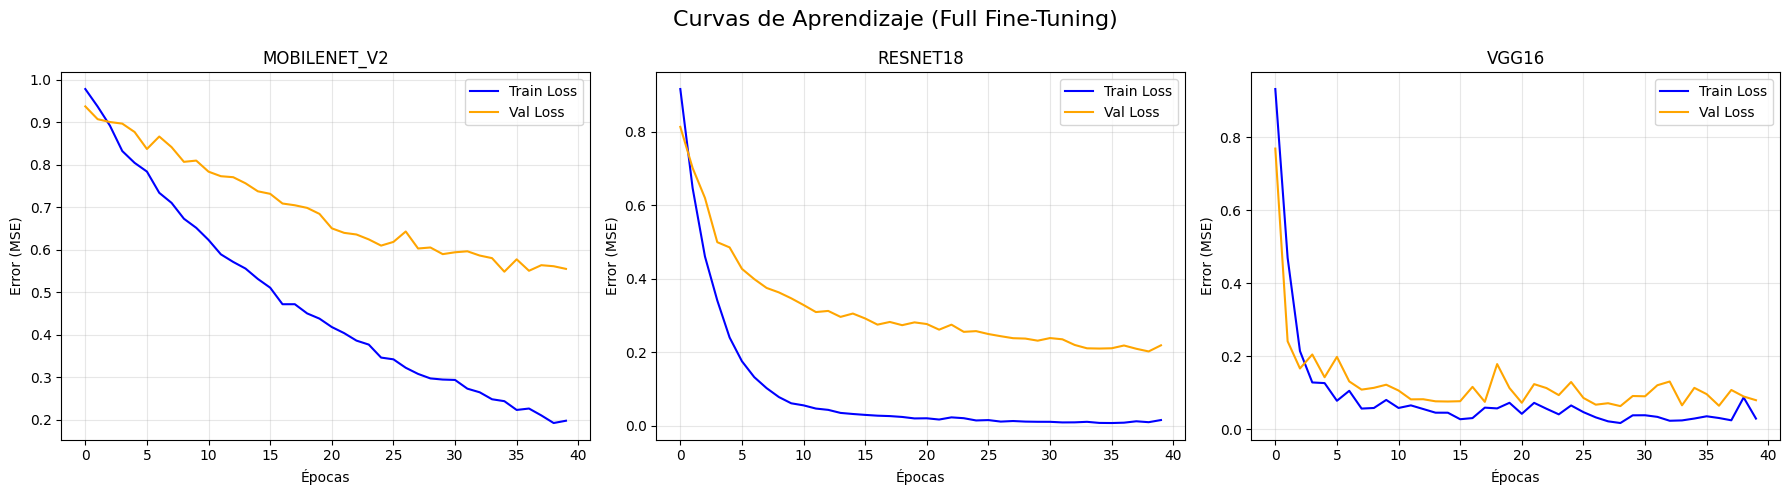


🏆 TABLA DE RESULTADOS FINALES (CON R²) 🏆
MODELO          | ACCURACY ±5°    | ACCURACY ±15°   | R² GLOBAL 
-----------------------------------------------------------------
MOBILENET_V2    |       8.13%    |      22.74%    |   -0.1525
RESNET18        |      27.29%    |      61.07%    |    0.5538
VGG16           |      57.27%    |      92.99%    |    0.8671


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score



model_names = ['mobilenet_v2', 'resnet18', 'vgg16']
resultados_transfer = {}

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Curvas de Aprendizaje (Full Fine-Tuning)', fontsize=16)

for idx, name in enumerate(model_names):
    print(f"   Entrenando modelo: {name.upper()}")
    
    # Crear modelo y optimizador
    model_ft = build_finetuning_model(model_name=name).to(device)
    optimizer_ft = torch.optim.AdamW(model_ft.parameters(), lr=5e-5, weight_decay=1e-4)
    
    # Entrenar
    print("Iniciando entrenamiento")
    history_ft = train_loop(
        train_loader2, val_loader2, model_ft, trig_loss, 
        optimizer_ft, epochs=40, device=device, trace=5
    )
    
    # Evaluar Accuracy
    print(f"\n Evaluando {name.upper()} en Test ")
    acc5  = trig_accuracy(test_loader2, model_ft, device=device, thr_deg=5)
    acc15 = trig_accuracy(test_loader2, model_ft, device=device, thr_deg=15)
    
    # Evaluar R-Cuadrado 
    r2_global, r2_cos, r2_sin = calcular_r2_trigonometrico(test_loader2, model_ft, device=device)
    
    print(f"Accuracy ±5°:  {acc5*100:.2f}%")
    print(f"Accuracy ±15°: {acc15*100:.2f}%")
    print(f"R² Global:     {r2_global:.4f} (Cos: {r2_cos:.2f} | Sin: {r2_sin:.2f})")
    
    # Guardar resultados
    resultados_transfer[name] = {
        'history': history_ft, 
        'acc5': acc5, 
        'acc15': acc15,
        'r2': r2_global
    }
    
    # Dibujar gráfica
    axs[idx].plot(history_ft['train_loss'], label='Train Loss', color='blue')
    axs[idx].plot(history_ft['val_loss'], label='Val Loss', color='orange')
    axs[idx].set_title(name.upper())
    axs[idx].set_xlabel('Épocas')
    axs[idx].set_ylabel('Error (MSE)')
    axs[idx].legend()
    axs[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("Tabla de resultados finales (con R²)")

print(f"{'Modelo':<15} | {'Accuracy ±5°':<15} | {'Accuracy ±15°':<15} | {'R² Global':<10}")

for name, data in resultados_transfer.items():
    print(f"{name.upper():<15} | {data['acc5']*100:>10.2f}%    | {data['acc15']*100:>10.2f}%    | {data['r2']:>9.4f}")


#### Conclusión de los resultados obtenidos con Fine-Tuning

Observamos que el uso de **fine-tuning completo en modelos preentrenados** produce mejoras significativas en el rendimiento respecto a enfoques más simples. En particular, los resultados muestran que **VGG16 es el modelo que mejor desempeño alcanza**, con una precisión muy alta (≈93% en ±15° y ≈57% en ±5°) y un valor de R² elevado (~0.87), lo que indica una excelente capacidad para predecir correctamente la orientación de las flechas. Por su parte, **ResNet18 ofrece un rendimiento intermedio**, logrando un buen equilibrio entre precisión y estabilidad (R² ≈ 0.55), mientras que **MobileNetV2 presenta los peores resultados**, con baja precisión y un R² negativo, lo que sugiere que no logra capturar adecuadamente la relación entre las imágenes y los ángulos en este problema.

El análisis de las **curvas de aprendizaje** refuerza estas conclusiones: VGG16 y ResNet18 muestran una convergencia rápida y estable, con baja diferencia entre entrenamiento y validación, mientras que MobileNetV2 presenta mayor error y peor generalización. En conjunto, concluimos que **los modelos más profundos y con mayor capacidad (como VGG16)** se adaptan mejor a este problema cuando se aplica fine-tuning completo, logrando una representación más precisa de la información angular.

---

## Conclusión general: comparación entre CNN desde cero, transfer learning congelado y fine-tuning

A partir de los resultados obtenidos, se pueden extraer conclusiones claras sobre el comportamiento de las distintas estrategias.

En primer lugar, el **transfer learning con el modelo completamente congelado** muestra un rendimiento claramente insuficiente, con valores de accuracy muy bajos y R² negativos. Esto indica que las características preentrenadas no son directamente transferibles a esta tarea sin adaptación, especialmente al tratarse de un problema de regresión angular.

En segundo lugar, al aplicar **fine-tuning (descongelando los pesos)**, se observa una mejora muy significativa en todos los modelos. En particular, **VGG16 alcanza los mejores resultados globales** (R² ≈ 0.87 y más del 92% de acierto en ±15°), lo que demuestra que ajustar los pesos internos permite adaptar eficazmente las representaciones al problema. No obstante, esta mejora viene acompañada de un **alto coste computacional y mayor tiempo de entrenamiento**.

Por último, la **CNN diseñada desde cero** ofrece un rendimiento muy competitivo, con resultados cercanos a los obtenidos por VGG16 en fine-tuning (≈91% en ±15° y error medio de ~10.75°). Esto indica que, con un diseño adecuado, es posible aprender representaciones eficaces sin necesidad de modelos preentrenados, aunque requiere un entrenamiento completo desde el inicio.

Aunque una desventaja de la CNN es que se entreno especificamente para este dataset, lo que puede limitar su generalización a otros datasets. Mientras que las redes preentrenadas como VGG16 y ResNet18 tienen una mejor capacidad de generalización debido a que han sido entrenadas en un conjunto amplio de datos, lo que les permite capturar características más generales y útiles para diferentes tareas.

En conjunto, se concluye que:
- El **modelo congelado no es adecuado** para esta tarea.
- El **fine-tuning es la estrategia más precisa**, especialmente con VGG16, pero más costosa.
- La **CNN propia representa el mejor compromiso**, logrando un rendimiento similar con menor complejidad conceptual y mayor control sobre la arquitectura.

Por tanto, la elección final depende del equilibrio deseado entre **precisión, coste computacional y simplicidad del modelo**.

Enlace al chat con IA: https://gemini.google.com/share/d7227ccac5d7